In [1]:
%pip install pandas matplotlib seaborn folium

Defaulting to user installation because normal site-packages is not writeable

   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   ---------------------------------------- 3/3 [folium]

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd

# 1. Use nrows=5 to read ONLY the first 5 rows for a quick structure check
df_sample = pd.read_csv('US_Accidents_March23.csv', nrows=5)

print('--- Sample Structural Check ---')
print('Total Features/Columns available:')
print(df_sample.columns.tolist())

# 2. Display the sample structure cleanly
df_sample.head(3)

--- Sample Structural Check ---
Total Features/Columns available:
['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster

sns.set_style("darkgrid")
plt.rcParams.update({"font.size": 12})

print("Step 1: Loading a memory-safe subset of 100,000 rows...")
df = pd.read_csv('US_Accidents_March23.csv', nrows=100000)
print(f"Loaded {len(df):,} rows and {df.shape[1]} columns.\n")

print("Step 2: Parsing Start_Time to datetime and extracting Hour...")
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['Hour'] = df['Start_Time'].dt.hour
missing_datetimes = df['Start_Time'].isna().sum()
print(f"Parsed Start_Time. Missing datetime rows: {missing_datetimes:,}.\n")

print('Step 3: Preparing weather condition text cleaning...')
df['Weather_Condition'] = (
    df['Weather_Condition']
      .astype(str)
      .str.strip()
      .replace({'nan': pd.NA, '': pd.NA})
)
print('Weather condition cleanup completed.\n')

Loading a subset of the dataset safely...
Data subset loaded and processed successfully!
Working with 100000 rows for visualization data.


🔄 Step 1: Loading 100,000 rows from the dataset safely...
📅 Step 2: Parsing dates and creating time components...
✅ Data successfully loaded! Shape: 100000 rows, 48 columns.

📊 Generating Plot 1: Time of Day Distribution...


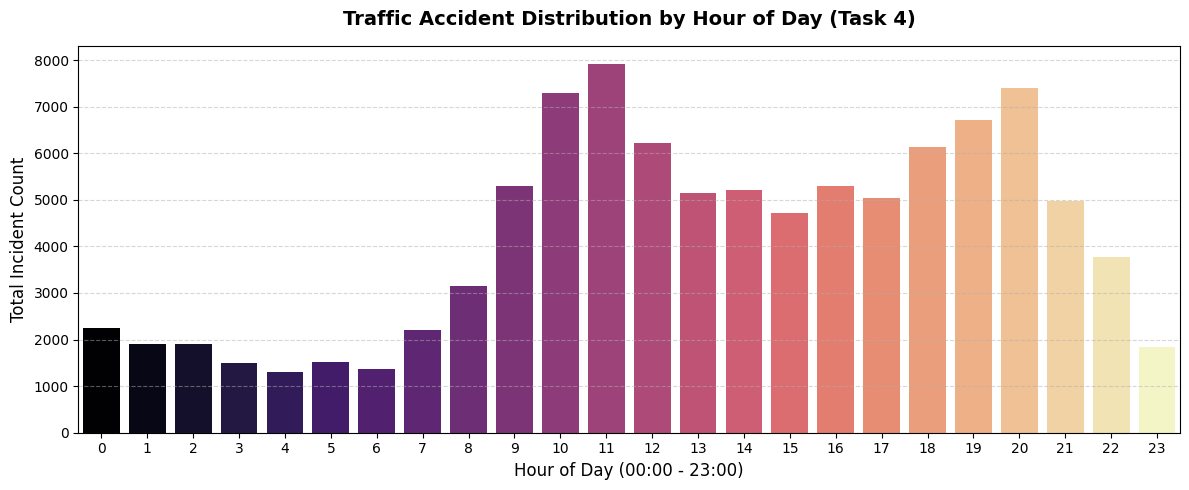

🌦️ Generating Plot 2: Top Weather Conditions...


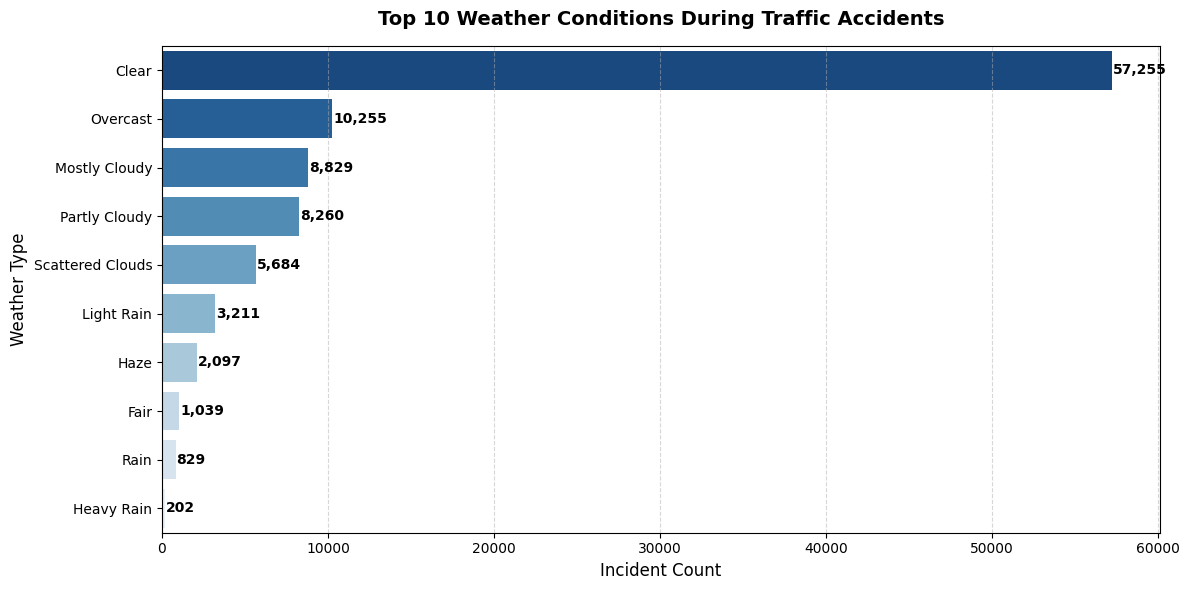

🗺️ Generating Plot 3: Interactive Geospatial Hotspot Map...
💾 Standalone map saved locally as 'accident_hotspots.html'


In [ ]:
print('Step 4: Plotting accident distribution by hour...')
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='Hour', palette='magma')
plt.title('Accident Distribution by Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day (0-23)', fontsize=13)
plt.ylabel('Accident Count', fontsize=13)
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('Step 5: Plotting top 10 weather conditions...')
plt.figure(figsize=(12, 6))
top_weather = df['Weather_Condition'].value_counts(dropna=True).head(10)
sns.barplot(x=top_weather.values, y=top_weather.index, palette='Blues_r')
for index, value in enumerate(top_weather.values):
    plt.text(value + max(top_weather.values) * 0.01, index, f'{value:,}', va='center', fontsize=10)
plt.title('Top 10 Weather Conditions During Traffic Accidents', fontsize=16, fontweight='bold')
plt.xlabel('Incident Count', fontsize=13)
plt.ylabel('Weather Condition', fontsize=13)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('Step 6: Creating the interactive hotspot map...')
map_df = df.dropna(subset=['Start_Lat', 'Start_Lng']).head(1000)
print(f'Using {len(map_df):,} coordinate rows for mapping.')

center_lat = map_df['Start_Lat'].median()
center_lng = map_df['Start_Lng'].median()
traffic_map = folium.Map(location=[center_lat, center_lng], zoom_start=5, control_scale=True)
marker_cluster = MarkerCluster().add_to(traffic_map)
for _, row in map_df.iterrows():
    folium.Marker(
        location=[row['Start_Lat'], row['Start_Lng']],
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(marker_cluster)
traffic_map.save('accident_hotspots.html')
print('Saved interactive hotspot map as accident_hotspots.html.')
traffic_map